# Lab 5: Frequent Pattern Mining – FP-Growth

**Name:** Amit Bhowmik  
**Department:** Computer Science and Engineering  
**ID:** 232031017  
**University:** Feni University

### Objectives
- Understand FP-tree construction
- Understand the FP-Growth algorithm
- Mine frequent itemsets
- Generate association rules from FP-Growth results
- Compare Apriori and FP-Growth

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

sns.set_theme(style="whitegrid")

### FP-Growth Algorithm

FP-Growth is a frequent pattern mining algorithm that avoids explicit candidate generation. It compresses the transaction database into an **FP-tree** and mines frequent patterns from the compressed structure.

The main steps are:

1. Count item frequencies.
2. Remove items below minimum support.
3. Order frequent items by descending frequency.
4. Insert the ordered transactions into an FP-tree.
5. Mine conditional pattern bases and conditional FP-trees.

### Transaction Dataset

The same market-basket dataset from Lab 4 is used so that Apriori and FP-Growth can be compared fairly.

In [2]:
transactions = [
    ["Milk", "Bread", "Butter"],
    ["Bread", "Diapers", "Beer", "Eggs"],
    ["Milk", "Bread", "Diapers", "Beer"],
    ["Bread", "Milk", "Diapers", "Beer"],
    ["Milk", "Bread", "Butter", "Eggs"],
    ["Bread", "Butter"],
    ["Milk", "Bread", "Diapers"],
    ["Bread", "Diapers", "Beer"],
    ["Milk", "Bread", "Butter"],
    ["Milk", "Diapers", "Beer", "Eggs"],
    ["Bread", "Milk", "Butter", "Diapers"],
    ["Bread", "Milk", "Beer"]
]

print("Number of transactions:", len(transactions))

Number of transactions: 12


In [3]:
te = TransactionEncoder()

encoded_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(
    encoded_array,
    columns=te.columns_
)

basket

,Beer,Bread,Butter,Diapers,Eggs,Milk
0,False,True,True,False,False,True
1,True,True,False,True,True,False
2,True,True,False,True,False,True
3,True,True,False,True,False,True
4,False,True,True,False,True,True
5,False,True,True,False,False,False
6,False,True,False,True,False,True
7,True,True,False,True,False,False
8,False,True,True,False,False,True
9,True,False,False,True,True,True


### Minimum Support

The minimum support is set to **0.30**. Only items that occur in at least 30% of the transactions are kept for the FP-tree.

In [4]:
min_support = 0.30

item_support = basket.mean().sort_values(ascending=False)

frequent_items = item_support[
    item_support >= min_support
]

frequent_items

Bread      0.916667
Milk       0.750000
Diapers    0.583333
Beer       0.500000
Butter     0.416667
dtype: float64

### FP-Tree Construction

The following simple FP-tree implementation demonstrates how transactions are compressed using shared prefixes. Each node stores an item, its count, and its children.

This is an educational construction of the tree. The actual FP-Growth mining is performed by `mlxtend.frequent_patterns.fpgrowth`.

In [5]:
class FPNode:
    def __init__(self, item=None, count=0, parent=None):
        self.item = item
        self.count = count
        self.parent = parent
        self.children = {}

    def add_child(self, item):
        child = FPNode(
            item=item,
            count=0,
            parent=self
        )
        self.children[item] = child
        return child


def build_fp_tree(transactions, min_support=0.30):
    transaction_count = len(transactions)

    item_counts = {}

    for transaction in transactions:
        for item in transaction:
            item_counts[item] = item_counts.get(item, 0) + 1

    min_count = min_support * transaction_count

    frequent_counts = {
        item: count
        for item, count in item_counts.items()
        if count >= min_count
    }

    root = FPNode(item=None, count=0)

    for transaction in transactions:
        filtered_transaction = [
            item
            for item in transaction
            if item in frequent_counts
        ]

        ordered_transaction = sorted(
            filtered_transaction,
            key=lambda item: (
                -frequent_counts[item],
                item
            )
        )

        current = root

        for item in ordered_transaction:
            if item in current.children:
                current = current.children[item]
                current.count += 1
            else:
                current = current.add_child(item)
                current.count = 1

    return root, frequent_counts

In [6]:
fp_root, fp_item_counts = build_fp_tree(
    transactions,
    min_support=min_support
)

print("Frequent item counts:")
print(fp_item_counts)

Frequent item counts:
{'Milk': 9, 'Bread': 11, 'Butter': 5, 'Diapers': 7, 'Beer': 6}


### Display FP-Tree

The tree is displayed recursively so that shared prefixes and their counts can be observed.

In [7]:
def print_fp_tree(node, level=0):
    for child in node.children.values():
        print(
            "  " * level
            + f"{child.item}: {child.count}"
        )
        print_fp_tree(child, level + 1)


print("FP-Tree:")
print_fp_tree(fp_root)

FP-Tree:
Bread: 11
  Milk: 8
    Butter: 3
    Diapers: 4
      Beer: 2
      Butter: 1
    Beer: 1
  Diapers: 2
    Beer: 2
  Butter: 1
Milk: 1
  Diapers: 1
    Beer: 1


### Apply FP-Growth

`fpgrowth()` directly mines frequent itemsets from the one-hot encoded transaction matrix. Unlike Apriori, FP-Growth does not require explicit candidate generation.

In [8]:
start_time = time.perf_counter()

frequent_itemsets_fp = fpgrowth(
    basket,
    min_support=min_support,
    use_colnames=True
)

fp_growth_time = time.perf_counter() - start_time

frequent_itemsets_fp = frequent_itemsets_fp.sort_values(
    by="support",
    ascending=False
).reset_index(drop=True)

frequent_itemsets_fp

,support,itemsets
0,0.916667,frozenset({Bread})
1,0.750000,frozenset({Milk})
2,0.666667,"frozenset({Bread, Milk})"
3,0.583333,frozenset({Diapers})
4,0.500000,frozenset({Beer})
5,0.500000,"frozenset({Bread, Diapers})"
6,0.416667,"frozenset({Bread, Butter})"
7,0.416667,frozenset({Butter})
8,0.416667,"frozenset({Bread, Beer})"
9,0.416667,"frozenset({Milk, Diapers})"


In [9]:
frequent_itemsets_fp["itemset_size"] = (
    frequent_itemsets_fp["itemsets"].apply(len)
)

frequent_itemsets_fp

,support,itemsets,itemset_size
0,0.916667,frozenset({Bread}),1
1,0.750000,frozenset({Milk}),1
2,0.666667,"frozenset({Bread, Milk})",2
3,0.583333,frozenset({Diapers}),1
4,0.500000,frozenset({Beer}),1
5,0.500000,"frozenset({Bread, Diapers})",2
6,0.416667,"frozenset({Bread, Butter})",2
7,0.416667,frozenset({Butter}),1
8,0.416667,"frozenset({Bread, Beer})",2
9,0.416667,"frozenset({Milk, Diapers})",2


### Frequent Itemsets

The number of frequent itemsets discovered at each size can be visualized.

In [10]:
itemset_counts_fp = (
    frequent_itemsets_fp["itemset_size"]
    .value_counts()
    .sort_index()
)

itemset_counts_fp

itemset_size
1    5
2    8
3    3
Name: count, dtype: int64

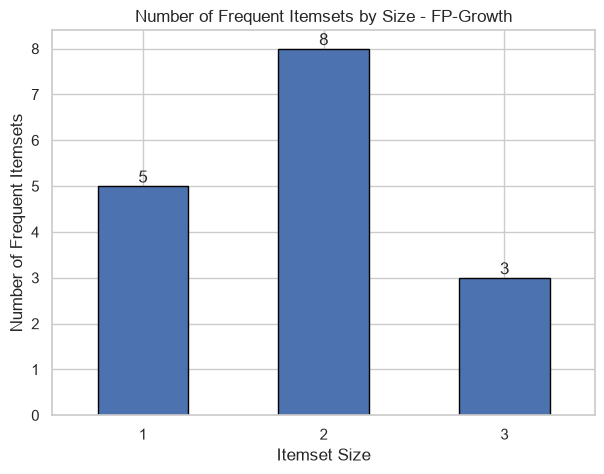

In [11]:
plt.figure(figsize=(7, 5))

ax = itemset_counts_fp.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Number of Frequent Itemsets by Size - FP-Growth")
plt.xlabel("Itemset Size")
plt.ylabel("Number of Frequent Itemsets")

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=0)
plt.show()

### Generate Association Rules

Association rules can be generated from the FP-Growth frequent itemsets using the same support, confidence, and lift measures used in Apriori.

In [12]:
rules_fp = association_rules(
    frequent_itemsets_fp,
    metric="confidence",
    min_threshold=0.60
)

rules_fp = rules_fp.sort_values(
    by=["lift", "confidence"],
    ascending=False
).reset_index(drop=True)

rules_fp[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
]

,antecedents,consequents,support,confidence,lift
0,frozenset({Beer}),frozenset({Diapers}),0.416667,0.833333,1.428571
1,frozenset({Diapers}),frozenset({Beer}),0.416667,0.714286,1.428571
2,"frozenset({Bread, Beer})",frozenset({Diapers}),0.333333,0.800000,1.371429
3,"frozenset({Bread, Diapers})",frozenset({Beer}),0.333333,0.666667,1.333333
4,frozenset({Beer}),"frozenset({Bread, Diapers})",0.333333,0.666667,1.333333
5,frozenset({Butter}),"frozenset({Bread, Milk})",0.333333,0.800000,1.200000
6,frozenset({Butter}),frozenset({Bread}),0.416667,1.000000,1.090909
7,"frozenset({Butter, Milk})",frozenset({Bread}),0.333333,1.000000,1.090909
8,frozenset({Butter}),frozenset({Milk}),0.333333,0.800000,1.066667
9,"frozenset({Bread, Butter})",frozenset({Milk}),0.333333,0.800000,1.066667


In [13]:
rules_fp_display = rules_fp[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].copy()

rules_fp_display["antecedents"] = rules_fp_display[
    "antecedents"
].apply(lambda x: ", ".join(sorted(x)))

rules_fp_display["consequents"] = rules_fp_display[
    "consequents"
].apply(lambda x: ", ".join(sorted(x)))

rules_fp_display["support"] = rules_fp_display["support"].round(3)
rules_fp_display["confidence"] = rules_fp_display["confidence"].round(3)
rules_fp_display["lift"] = rules_fp_display["lift"].round(3)

rules_fp_display

,antecedents,consequents,support,confidence,lift
0,Beer,Diapers,0.417,0.833,1.429
1,Diapers,Beer,0.417,0.714,1.429
2,"Beer, Bread",Diapers,0.333,0.800,1.371
3,"Bread, Diapers",Beer,0.333,0.667,1.333
4,Beer,"Bread, Diapers",0.333,0.667,1.333
5,Butter,"Bread, Milk",0.333,0.800,1.200
6,Butter,Bread,0.417,1.000,1.091
7,"Butter, Milk",Bread,0.333,1.000,1.091
8,Butter,Milk,0.333,0.800,1.067
9,"Bread, Butter",Milk,0.333,0.800,1.067


### Compare Apriori and FP-Growth

Both algorithms should discover the same frequent itemsets when the input data and minimum support are identical. Their main difference is how they search for those itemsets.

- **Apriori:** generates candidate itemsets and repeatedly tests them.
- **FP-Growth:** builds a compressed FP-tree and mines patterns without explicit candidate generation.

In [14]:
start_time = time.perf_counter()

frequent_itemsets_apriori = apriori(
    basket,
    min_support=min_support,
    use_colnames=True
)

apriori_time = time.perf_counter() - start_time

frequent_itemsets_apriori = frequent_itemsets_apriori.sort_values(
    by="support",
    ascending=False
).reset_index(drop=True)

frequent_itemsets_apriori

,support,itemsets
0,0.916667,frozenset({Bread})
1,0.750000,frozenset({Milk})
2,0.666667,"frozenset({Bread, Milk})"
3,0.583333,frozenset({Diapers})
4,0.500000,"frozenset({Bread, Diapers})"
5,0.500000,frozenset({Beer})
6,0.416667,frozenset({Butter})
7,0.416667,"frozenset({Bread, Beer})"
8,0.416667,"frozenset({Bread, Butter})"
9,0.416667,"frozenset({Diapers, Beer})"


In [15]:
comparison = pd.DataFrame({
    "Algorithm": ["Apriori", "FP-Growth"],
    "Execution Time (seconds)": [
        apriori_time,
        fp_growth_time
    ],
    "Frequent Itemsets": [
        len(frequent_itemsets_apriori),
        len(frequent_itemsets_fp)
    ]
})

comparison

,Algorithm,Execution Time (seconds),Frequent Itemsets
0,Apriori,0.003510,16
1,FP-Growth,0.002321,16


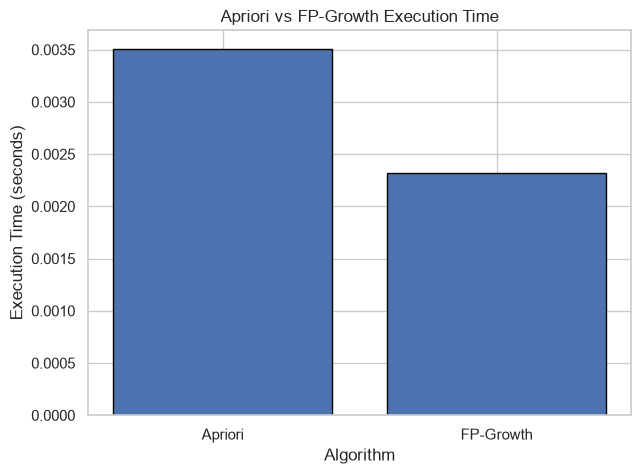

In [16]:
plt.figure(figsize=(7, 5))

plt.bar(
    comparison["Algorithm"],
    comparison["Execution Time (seconds)"],
    edgecolor="black"
)

plt.title("Apriori vs FP-Growth Execution Time")
plt.xlabel("Algorithm")
plt.ylabel("Execution Time (seconds)")

plt.show()

### Verify Frequent Itemsets

The two algorithms should produce the same set of frequent itemsets for the same minimum support. Because itemset ordering can differ, the sets are compared independently of row order.

In [17]:
apriori_sets = {
    frozenset(itemset)
    for itemset in frequent_itemsets_apriori["itemsets"]
}

fp_growth_sets = {
    frozenset(itemset)
    for itemset in frequent_itemsets_fp["itemsets"]
}

print("Apriori itemsets:", len(apriori_sets))
print("FP-Growth itemsets:", len(fp_growth_sets))
print("Same frequent itemsets:", apriori_sets == fp_growth_sets)

Apriori itemsets: 16
FP-Growth itemsets: 16
Same frequent itemsets: True


### Comparison Summary

| Feature | Apriori | FP-Growth |
|---|---|---|
| Candidate generation | Yes | No |
| Main structure | Candidate itemsets | FP-tree |
| Database compression | Limited | Yes |
| Search strategy | Candidate generation and testing | Pattern growth |
| Typical performance | Can become expensive for large datasets | Usually more efficient for large transactional datasets |

The small dataset used in this lab is useful for understanding the algorithms, but execution-time differences become more meaningful on larger transactional datasets.

### Conclusion

FP-Growth was successfully applied to mine frequent itemsets from transactional data. An educational FP-tree was constructed to demonstrate the underlying data structure, and `mlxtend` was used to perform FP-Growth mining and association-rule generation.

The comparison with Apriori shows the key conceptual advantage of FP-Growth: it avoids explicit candidate generation by using a compressed FP-tree and pattern-growth strategy.